# 02 — Data Preprocessing & Stratified Split

**Day:** 2 of the project plan
**Goal:** turn the raw image folders into deterministic train / val / test CSVs that
every model in Days 3-5 will load identically. Also nail down the augmentation policy.

This notebook has three jobs:
1. Decide and document the input format (size, channels, value range).
2. Build a stratified 70 / 15 / 15 split — *file-list level only, no pixels copied*.
3. Define a light augmentation policy (rotation / shift / zoom; **no horizontal flip**)
   and visualize a few augmented examples so a human can confirm "light" is actually light.

> **Limitation reminder:** the dataset is augmented and upsampled. Image-level splitting
> can leak near-duplicates across train / val / test. We split by image only because the
> dataset doesn't expose patient/scan IDs — the limitation belongs in the final report.


## 0. Environment setup

In [1]:
import os, sys
from pathlib import Path

# Select Keras backend BEFORE importing anything that touches keras.
# 'torch' = native Windows GPU on RTX 5080. Override to 'tensorflow' on Colab if desired.
os.environ.setdefault("KERAS_BACKEND", "torch")

def _find_project_root():
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Could not find src/config.py.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import google.colab; IN_COLAB = True
    from google.colab import drive; drive.mount("/content/drive", force_remount=False)
except ImportError:
    IN_COLAB = False
print("In Colab:", IN_COLAB, "  Keras backend:", os.environ["KERAS_BACKEND"])


In Colab: False   Keras backend: torch


In [2]:
from src.config import (
    summary, set_global_seed, DATA_ROOT, IMG_SIZE, IMG_CHANNELS,
    BATCH_SIZE, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, SEED, CLASS_NAMES, NUM_CLASSES,
)
print(summary())
print(f"Splits: train={TRAIN_FRAC}, val={VAL_FRAC}, test={TEST_FRAC}")
set_global_seed()


Environment: local
Project root: C:\Users\miaot\Github\Project_DeepLearningClass
Data root:    C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images
Outputs:      C:\Users\miaot\Github\Project_DeepLearningClass\outputs
Classes:      ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
Image size:   128x128x3
Seed:         42

Splits: train=0.7, val=0.15, test=0.15


## 1. Input format decisions

| Knob | Value | Why |
|---|---|---|
| Image size | 128×128 | Day 1 showed sizes are non-uniform (200×190, 180×180, 176×208). 128² is enough for the baseline CNN and lets MobileNetV2 / VGG16 fit comfortably in Colab. |
| Channels | 3 (RGB) | Day 1 showed ~30% of images come in as grayscale. Forcing 3 channels everywhere lets us reuse one pipeline for the baseline CNN *and* the ImageNet-pretrained backbones. |
| Value range | [0, 1] | Plain `/255.0` normalization. We rely on Keras's per-backbone preprocessing layer (`preprocess_input`) where it matters (MobileNetV2 / VGG16). |

## 2. Stratified 70 / 15 / 15 split

We do this in two steps with `sklearn.model_selection.train_test_split`:
1. `train_test_split(df, train_size=0.70, stratify=labels)` → train vs (val+test).
2. `train_test_split(rest, test_size=0.50, stratify=labels)` → val vs test.

Both calls pass `stratify=`, so each class keeps the same proportion in every split.
The inputs come from `list_images`, which sorts within each class folder, so the
resulting splits are fully deterministic at `seed=42`.

In [3]:
from src.preprocessing import run_preprocessing
import json
split_summary = run_preprocessing()
print(json.dumps(split_summary, indent=2))


[01:20:15] INFO Listing images under C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images


[01:20:16] INFO Total images: 44000


[01:20:16] INFO Saved splits:
  train -> C:\Users\miaot\Github\Project_DeepLearningClass\outputs\splits\train.csv
  val   -> C:\Users\miaot\Github\Project_DeepLearningClass\outputs\splits\val.csv
  test  -> C:\Users\miaot\Github\Project_DeepLearningClass\outputs\splits\test.csv


[01:20:16] INFO Wrote split summary: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\reports\02_split_summary.json


{
  "train": {
    "total": 30799,
    "by_class": {
      "NonDemented": 8959,
      "VeryMildDemented": 7840,
      "MildDemented": 7000,
      "ModerateDemented": 7000
    }
  },
  "val": {
    "total": 6600,
    "by_class": {
      "NonDemented": 1920,
      "VeryMildDemented": 1680,
      "MildDemented": 1500,
      "ModerateDemented": 1500
    }
  },
  "test": {
    "total": 6601,
    "by_class": {
      "NonDemented": 1921,
      "VeryMildDemented": 1680,
      "MildDemented": 1500,
      "ModerateDemented": 1500
    }
  },
  "fractions": {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
  },
  "seed": 42,
  "elapsed_seconds": 0.52,
  "paths": {
    "train": "C:\\Users\\miaot\\Github\\Project_DeepLearningClass\\outputs\\splits\\train.csv",
    "val": "C:\\Users\\miaot\\Github\\Project_DeepLearningClass\\outputs\\splits\\val.csv",
    "test": "C:\\Users\\miaot\\Github\\Project_DeepLearningClass\\outputs\\splits\\test.csv"
  }
}


### Sanity check: per-class fractions are stable across splits

In [4]:
import pandas as pd
rows = []
for split in ["train", "val", "test"]:
    counts = split_summary[split]["by_class"]
    total = split_summary[split]["total"]
    for c, n in counts.items():
        rows.append({"split": split, "class": c, "count": n,
                     "share_within_split": round(n / total, 4)})
counts_df = pd.DataFrame(rows)
counts_df.pivot(index="class", columns="split", values="share_within_split")


split,test,train,val
class,,,
MildDemented,0.2272,0.2273,0.2273
ModerateDemented,0.2272,0.2273,0.2273
NonDemented,0.2910,0.2909,0.2909
VeryMildDemented,0.2545,0.2546,0.2545


If the table above shows roughly the same fractions across train / val / test for each class, the stratification worked.

## 3. Persisted split files

After this notebook runs, every Day 3-5 model loads the splits via `src.io_utils.load_split('train')`. There is no per-model splitting code — that would be the easiest way to introduce a subtle leak.

In [5]:
from src.io_utils import load_split
train_df = load_split("train"); val_df = load_split("val"); test_df = load_split("test")
print(f"train: {len(train_df):,}   val: {len(val_df):,}   test: {len(test_df):,}")
train_df.head()


train: 30,799   val: 6,600   test: 6,601


,relpath,class,label,filepath
0,VeryMildDemented/2c455df0-cb8e-4fb0-9b55-e408b...,VeryMildDemented,1,C:\Users\miaot\Github\Project_DeepLearningClas...
1,NonDemented/fc9ab1c1-ee41-419a-9ce6-03496de4a9...,NonDemented,0,C:\Users\miaot\Github\Project_DeepLearningClas...
2,NonDemented/b7483a38-1d35-4e2c-90cf-331709a701...,NonDemented,0,C:\Users\miaot\Github\Project_DeepLearningClas...
3,MildDemented/4b99b733-6eaa-44b4-8cc2-61a9787a0...,MildDemented,2,C:\Users\miaot\Github\Project_DeepLearningClas...
4,MildDemented/b3945aaa-3360-4326-a003-280c82af0...,MildDemented,2,C:\Users\miaot\Github\Project_DeepLearningClas...


## 4. Augmentation policy

The dataset has *already* been augmented and upsampled by the publisher, so our own
augmentation should be **light**. We use only:

| Augmentation | Magnitude | Notes |
|---|---|---|
| Rotation | ±10.8° (`RandomRotation(factor=0.03)`, where `factor` is a fraction of a full turn → 0.03 × 360°) | Plan recommends ≤10° |
| Translation | ±5% width / height | Small shifts only |
| Zoom | ±5% | Small zoom only |
| **Horizontal flip** | **NOT USED** | Plan flags it as risky for MRI — left/right brain asymmetry can be informative |

Augmentation is applied **only in the training pipeline**; val and test are clean.


Saved: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\02_augmentation_examples.png


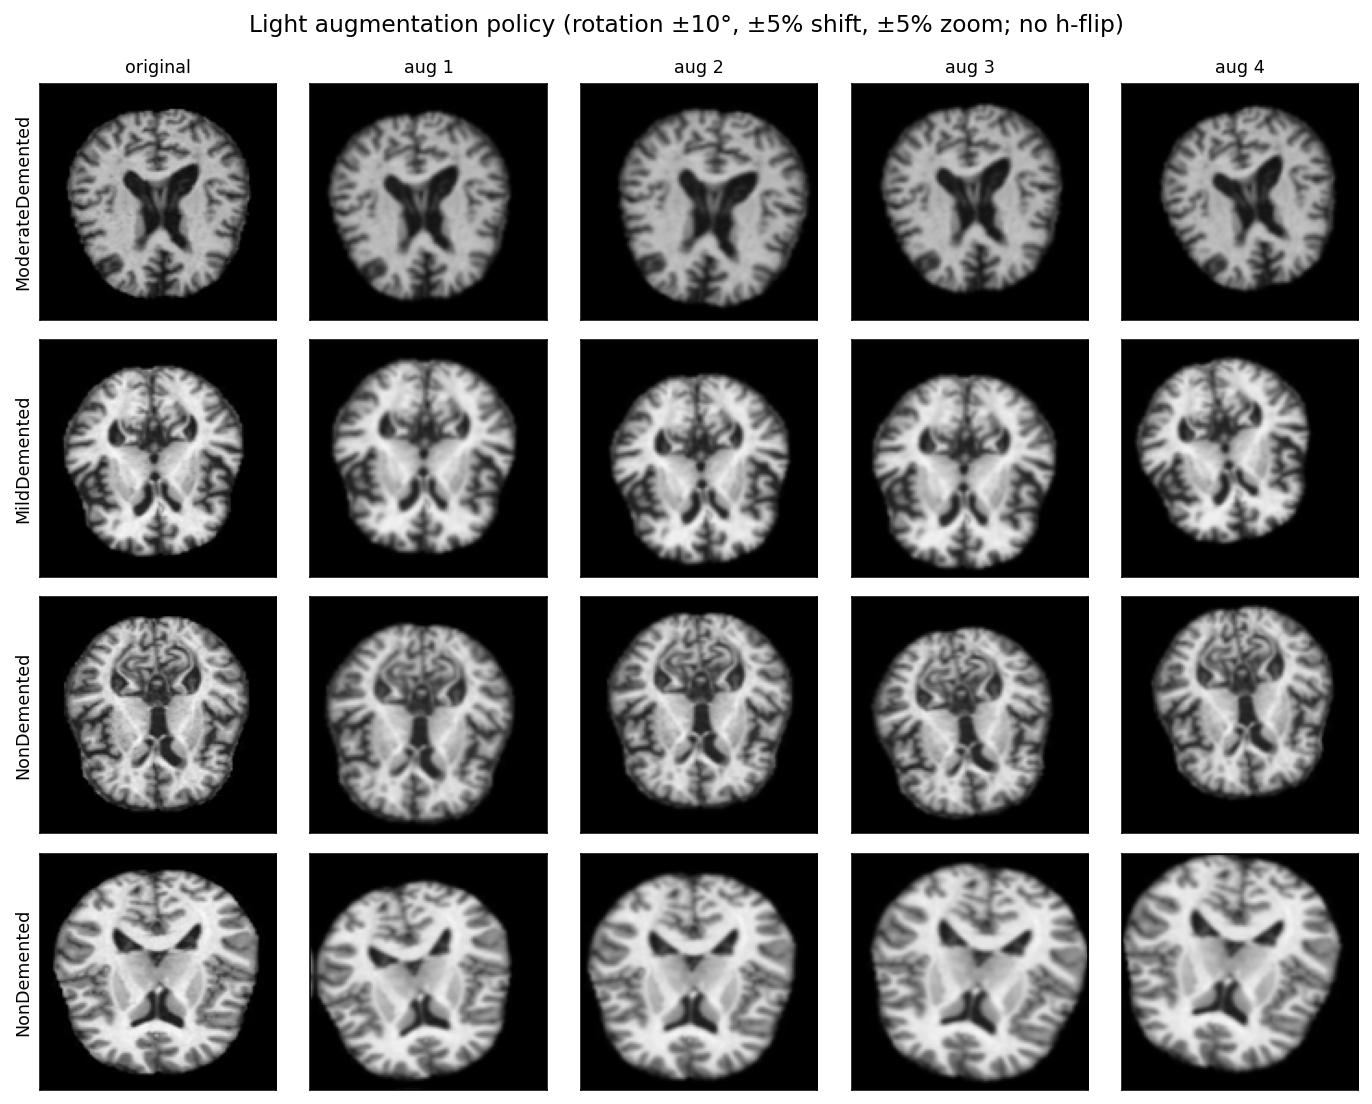

In [6]:
from src.preprocessing import visualize_augmentation
fig_path = visualize_augmentation(train_df, n_examples=4, n_aug_per_example=4)
print("Saved:", fig_path)
from IPython.display import Image as IPyImage
IPyImage(filename=str(fig_path))


Visually the augmented copies should look almost identical to the original — only a tiny rotation / shift / zoom. If they look distorted, the policy is too strong.

## 5. Data pipeline smoke test

Load one batch from each split and verify the shapes / dtype / value range.
This is the contract every model notebook will rely on. The pipeline is a Keras 3 `PyDataset` so it works on either TF or PyTorch backend.

In [7]:
from src.io_utils import make_keras_dataset

# small subsets for the smoke test so this cell is fast
train_ds = make_keras_dataset(train_df.head(96),  batch_size=32, shuffle=True,  augment=True)
val_ds   = make_keras_dataset(val_df.head(64),    batch_size=32, shuffle=False, augment=False)
test_ds  = make_keras_dataset(test_df.head(64),   batch_size=32, shuffle=False, augment=False)

import numpy as np
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    xb, yb = ds[0]   # PyDataset.__getitem__ returns one batch
    xb = np.asarray(xb); yb = np.asarray(yb)
    print(f"{name:5s} batch -> shape {xb.shape}  dtype {xb.dtype}  "
          f"min {float(xb.min()):.3f}  max {float(xb.max()):.3f}  "
          f"labels {sorted(set(int(v) for v in yb.tolist()))}")

assert xb.shape == (32, 128, 128, 3) and xb.dtype == np.float32
print("PASS: pipeline produces (32, 128, 128, 3) float32 batches in [0, 1].")


train batch -> shape (32, 128, 128, 3)  dtype float32  min 0.000  max 1.000  labels [0, 1, 2, 3]
val   batch -> shape (32, 128, 128, 3)  dtype float32  min 0.000  max 1.000  labels [0, 1, 2, 3]
test  batch -> shape (32, 128, 128, 3)  dtype float32  min 0.000  max 1.000  labels [0, 1, 2, 3]
PASS: pipeline produces (32, 128, 128, 3) float32 batches in [0, 1].


## 6. Conclusions for Day 2

- Splits saved at `outputs/splits/{train,val,test}.csv` (deterministic at SEED=42).
- Stratification preserves the class fractions almost exactly.
- Augmentation policy is light per the plan (no horizontal flip).
- `make_tf_dataset` is the single entry point for every Day 3-5 model.

Next: **03_model_a_baseline_cnn.ipynb** — custom 4-block CNN trained from scratch.
